# KNN (K-Nearest Neighbors)

is a simple, instance-based learning algorithm used for classification and regression. For a given new point, it finds the `k` closest training examples in feature space, then:

- for classification: predicts the class most common among those neighbors,
- for regression: predicts the average value of the neighbors.

Distance is usually measured with Euclidean distance, though other metrics can be used. KNN does not build an explicit model; it stores the training data and makes predictions based on similarity to nearby examples.

In [55]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
from pathlib import Path

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Add the libs directory to Python path
current_dir = Path.cwd()
libs_dir = os.path.join(current_dir, '..', 'libs')
libs_dir = os.path.abspath(libs_dir)
print("Libs directory:", libs_dir)
sys.path.insert(0, libs_dir)

from utils import get_numerical_and_non_numerical_heatmap

dataset_dir = os.path.join(current_dir, '..', 'datasets')
models_dir = os.path.join(current_dir, '..', 'models')


Libs directory: /Users/kolithawarnakulasooriya/Projects/AI-driven-cyber-physical-system/libs


In [42]:
df = pd.read_csv(f"{dataset_dir}/firewall_data.csv")
df.head()

,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Action,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
0,57222,53,54587,53,allow,177,94,83,2,30,1,1
1,56258,3389,56258,3389,allow,4768,1600,3168,19,17,10,9
2,6881,50321,43265,50321,allow,238,118,120,2,1199,1,1
3,50553,3389,50553,3389,allow,3327,1438,1889,15,17,8,7
4,50002,443,45848,443,allow,25358,6778,18580,31,16,13,18


In [43]:
columns = df.columns.drop(['Source Port', 'Destination Port', 'pkts_received', 'Packets', 'NAT Source Port','NAT Destination Port', 'Bytes Received', 'Elapsed Time (sec)', 'pkts_sent'])
columns

Index(['Action', 'Bytes', 'Bytes Sent'], dtype='str')

In [44]:
df = df[columns.values.tolist()]
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65532 entries, 0 to 65531
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Action      65532 non-null  str  
 1   Bytes       65532 non-null  int64
 2   Bytes Sent  65532 non-null  int64
dtypes: int64(2), str(1)
memory usage: 1.5 MB


In [45]:
df = df[df['Action'].isin(['allow','deny'])].copy()
df['Action'] = df['Action'].map({'allow': 1, 'deny': 0}).astype(int)

df.head()

,Action,Bytes,Bytes Sent
0,1,177,94
1,1,4768,1600
2,1,238,118
3,1,3327,1438
4,1,25358,6778


In [46]:
X = df[columns.drop('Action')]
y = df['Action'].astype(int)

X = StandardScaler().fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [48]:
knn = KNeighborsClassifier(n_neighbors=3)

param_grid = {'n_neighbors': np.arange(1, 6, 1)}
knn_gscv = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')

knn_gscv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsCla...n_neighbors=3)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': array([1, 2, 3, 4, 5])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed durin

In [49]:
best_k = knn_gscv.best_params_['n_neighbors']
print(f"The mathematically optimal K value is: {best_k}")

The mathematically optimal K value is: 3


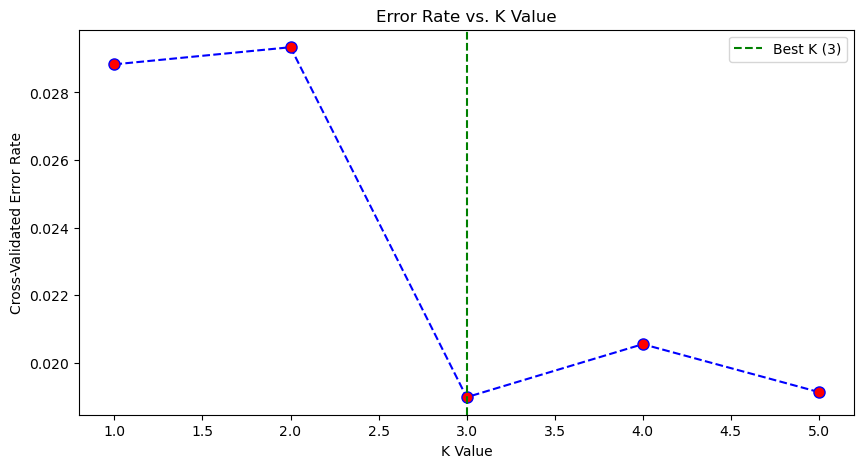

In [51]:
mean_scores = knn_gscv.cv_results_['mean_test_score']

plt.figure(figsize=(10, 5))
plt.plot(param_grid['n_neighbors'], 1 - mean_scores, color='blue', linestyle='dashed', marker='o', markerfacecolor='red',markersize=8)
plt.title('Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Cross-Validated Error Rate')
plt.axvline(x=best_k, color='green', linestyle='--', label=f'Best K ({best_k})')
plt.legend()
plt.show()

In [56]:
best_knn = knn_gscv.best_estimator_

y_pred = best_knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.4f}\n")

print("Classification report:")
print(classification_report(y_test, y_pred, target_names=['deny', 'allow']))

Test accuracy: 0.9826

Classification report:
              precision    recall  f1-score   support

        deny       0.96      0.98      0.97      3789
       allow       0.99      0.98      0.99      9368

    accuracy                           0.98     13157
   macro avg       0.98      0.98      0.98     13157
weighted avg       0.98      0.98      0.98     13157



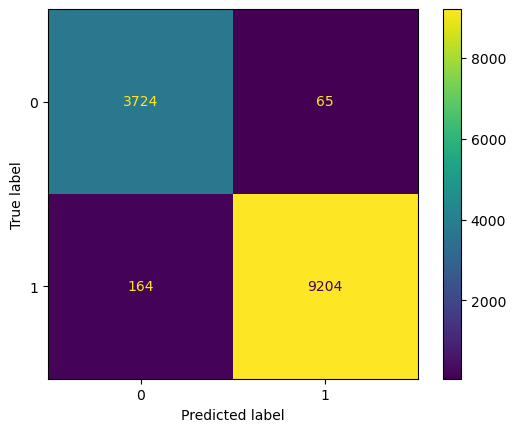

In [58]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_knn.classes_)
disp.plot()
plt.show()